In [93]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [94]:
rice_df = pd.read_csv("crop_production.csv")
rain_df = pd.read_csv("rainfall in india 1901-2015.csv")

print("Rice dataset shape:", rice_df.shape)
print("Rainfall dataset shape:", rain_df.shape)

Rice dataset shape: (15104, 7)
Rainfall dataset shape: (4116, 19)


In [95]:
print("Rice dataset columns:")
print(rice_df.columns)

print("\nRainfall dataset columns:")
print(rain_df.columns)

print("\nFirst 5 rows of rice dataset:")
print(rice_df.head())

print("\nFirst 5 rows of rainfall dataset:")
print(rain_df.head())

print("\nMissing values in rice dataset:")
print(rice_df.isnull().sum())

print("\nMissing values in rainfall dataset:")
print(rain_df.isnull().sum())

Rice dataset columns:
Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

Rainfall dataset columns:
Index(['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec'],
      dtype='object')

First 5 rows of rice dataset:
                    State_Name District_Name  Crop_Year       Season  Crop  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif       Rice   
1  Andaman and Nicobar Islands      NICOBARS       2001  Kharif       Rice   
2  Andaman and Nicobar Islands      NICOBARS       2002  Kharif       Rice   
3  Andaman and Nicobar Islands      NICOBARS       2003  Kharif       Rice   
4  Andaman and Nicobar Islands      NICOBARS       2004  Kharif       Rice   

     Area  Production  
0  102.00      321.00  
1   83.00      300.00  
2  189.20      510.84  
3   52.00       90.17  
4   5

In [96]:
def clean_text(x):
    if pd.isna(x):
        return x
    return str(x).replace("\xa0", " ").strip()

for col in ["State_Name", "District_Name", "Season", "Crop"]:
    rice_df[col] = rice_df[col].apply(clean_text)

rice_df = rice_df.dropna(subset=["Production", "Area"]).copy()
rice_df = rice_df[(rice_df["Area"] > 0) & (rice_df["Production"] > 0)].copy()

print("Rice dataset shape after cleaning:", rice_df.shape)

Rice dataset shape after cleaning: (15078, 7)


#Create the Target Variable: Yield

In [97]:
rice_df["Yield"] = rice_df["Production"] / rice_df["Area"]

print(rice_df[["Area", "Production", "Yield"]].head())
print("\nYield statistics:")
print(rice_df["Yield"].describe())

     Area  Production     Yield
0  102.00      321.00  3.147059
1   83.00      300.00  3.614458
2  189.20      510.84  2.700000
3   52.00       90.17  1.734038
4   52.94       72.57  1.370797

Yield statistics:
count    15078.000000
mean         1.995543
std          2.048701
min          0.003889
25%          1.275456
50%          1.938816
75%          2.565197
max        223.727273
Name: Yield, dtype: float64


In [98]:
rain_use = rain_df[[
    "SUBDIVISION",
    "YEAR",
    "ANNUAL",
    "Jan-Feb",
    "Mar-May",
    "Jun-Sep",
    "Oct-Dec"
]].copy()

rain_use.rename(columns={"YEAR": "Crop_Year"}, inplace=True)

print(rain_use.head())

                 SUBDIVISION  Crop_Year  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  \
0  ANDAMAN & NICOBAR ISLANDS       1901  3373.2    136.3    560.3   1696.3   
1  ANDAMAN & NICOBAR ISLANDS       1902  3520.7    159.8    458.3   2185.9   
2  ANDAMAN & NICOBAR ISLANDS       1903  2957.4    156.7    236.1   1874.0   
3  ANDAMAN & NICOBAR ISLANDS       1904  3079.6     24.1    506.9   1977.6   
4  ANDAMAN & NICOBAR ISLANDS       1905  2566.7      1.3    309.7   1624.9   

   Oct-Dec  
0    980.3  
1    716.7  
2    690.6  
3    571.0  
4    630.8  


#Map States to Rainfall Subdivisions
Explanation

The rice dataset uses State_Name, while the rainfall dataset uses SUBDIVISION.
To merge them, we create a mapping.

In [99]:
state_to_subdivision = {
    "Andaman and Nicobar Islands": "ANDAMAN & NICOBAR ISLANDS",
    "Andhra Pradesh": "COASTAL ANDHRA PRADESH",
    "Arunachal Pradesh": "ARUNACHAL PRADESH",
    "Assam": "ASSAM & MEGHALAYA",
    "Bihar": "BIHAR",
    "Chandigarh": "HARYANA DELHI & CHANDIGARH",
    "Chhattisgarh": "CHHATTISGARH",
    "Dadra and Nagar Haveli": "GUJARAT REGION",
    "Goa": "KONKAN & GOA",
    "Gujarat": "GUJARAT REGION",
    "Haryana": "HARYANA DELHI & CHANDIGARH",
    "Himachal Pradesh": "HIMACHAL PRADESH",
    "Jammu and Kashmir": "JAMMU & KASHMIR",
    "Jharkhand": "JHARKHAND",
    "Karnataka": "NORTH INTERIOR KARNATAKA",
    "Kerala": "KERALA",
    "Madhya Pradesh": "WEST MADHYA PRADESH",
    "Maharashtra": "MADHYA MAHARASHTRA",
    "Manipur": "NAGA MANI MIZO TRIPURA",
    "Meghalaya": "ASSAM & MEGHALAYA",
    "Mizoram": "NAGA MANI MIZO TRIPURA",
    "Nagaland": "NAGA MANI MIZO TRIPURA",
    "Odisha": "ORISSA",
    "Puducherry": "TAMIL NADU",
    "Punjab": "PUNJAB",
    "Rajasthan": "WEST RAJASTHAN",
    "Sikkim": "SUB HIMALAYAN WEST BENGAL & SIKKIM",
    "Tamil Nadu": "TAMIL NADU",
    "Telangana": "TELANGANA",
    "Tripura": "NAGA MANI MIZO TRIPURA",
    "Uttar Pradesh": "EAST UTTAR PRADESH",
    "Uttarakhand": "UTTARAKHAND",
    "West Bengal": "GANGETIC WEST BENGAL"
}

rice_df["SUBDIVISION"] = rice_df["State_Name"].map(state_to_subdivision)
rice_df = rice_df.dropna(subset=["SUBDIVISION"]).copy()

print("Rice dataset shape after mapping:", rice_df.shape)

Rice dataset shape after mapping: (15078, 9)


In [100]:
merged_df = pd.merge(
    rice_df,
    rain_use,
    on=["SUBDIVISION", "Crop_Year"],
    how="inner"
)

merged_df = merged_df.dropna(subset=["ANNUAL", "Jan-Feb", "Mar-May", "Jun-Sep", "Oct-Dec"]).copy()

print("Merged dataset shape:", merged_df.shape)
print(merged_df.head())

Merged dataset shape: (15033, 14)
                    State_Name District_Name  Crop_Year  Season  Crop    Area  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif  Rice  102.00   
1  Andaman and Nicobar Islands      NICOBARS       2001  Kharif  Rice   83.00   
2  Andaman and Nicobar Islands      NICOBARS       2002  Kharif  Rice  189.20   
3  Andaman and Nicobar Islands      NICOBARS       2003  Kharif  Rice   52.00   
4  Andaman and Nicobar Islands      NICOBARS       2004  Kharif  Rice   52.94   

   Production     Yield                SUBDIVISION  ANNUAL  Jan-Feb  Mar-May  \
0      321.00  3.147059  ANDAMAN & NICOBAR ISLANDS  2763.2    112.0    812.2   
1      300.00  3.614458  ANDAMAN & NICOBAR ISLANDS  3080.9    104.7    878.7   
2      510.84  2.700000  ANDAMAN & NICOBAR ISLANDS  2620.2     10.7    478.4   
3       90.17  1.734038  ANDAMAN & NICOBAR ISLANDS  2355.9     52.2    465.0   
4       72.57  1.370797  ANDAMAN & NICOBAR ISLANDS  2460.1     90.4    583.2   

#Remove Extreme Yield Outliers

In [101]:
lower_limit = merged_df["Yield"].quantile(0.01)
upper_limit = merged_df["Yield"].quantile(0.99)

merged_df = merged_df[
    (merged_df["Yield"] >= lower_limit) &
    (merged_df["Yield"] <= upper_limit)
].copy()

print("Dataset shape after outlier removal:", merged_df.shape)

Dataset shape after outlier removal: (14731, 14)


In [102]:
merged_df.to_csv("final_rice_rainfall_dataset.csv", index=False)
print("Final merged dataset saved successfully.")

Final merged dataset saved successfully.


#Exploratory Data Analysis
Explanation

EDA helps us understand:

yield distribution
rainfall impact
production by state
feature correlation

Set a plotting theme first:

In [103]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#Yield Distribution Plot

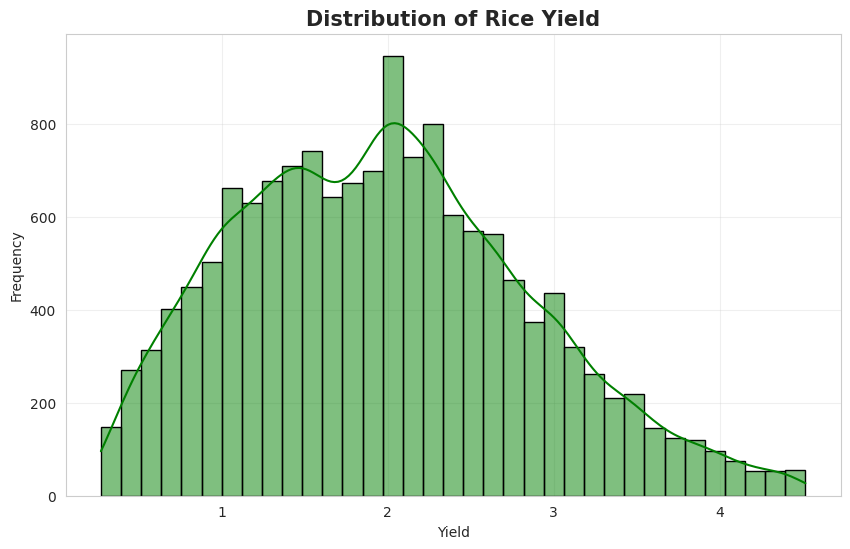

In [104]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(merged_df["Yield"], bins=35, kde=True, color="green", edgecolor="black")
plt.title("Distribution of Rice Yield", fontsize=15, weight="bold")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

This plot shows how yield values are spread across the dataset.

#Annual Rainfall vs Yield

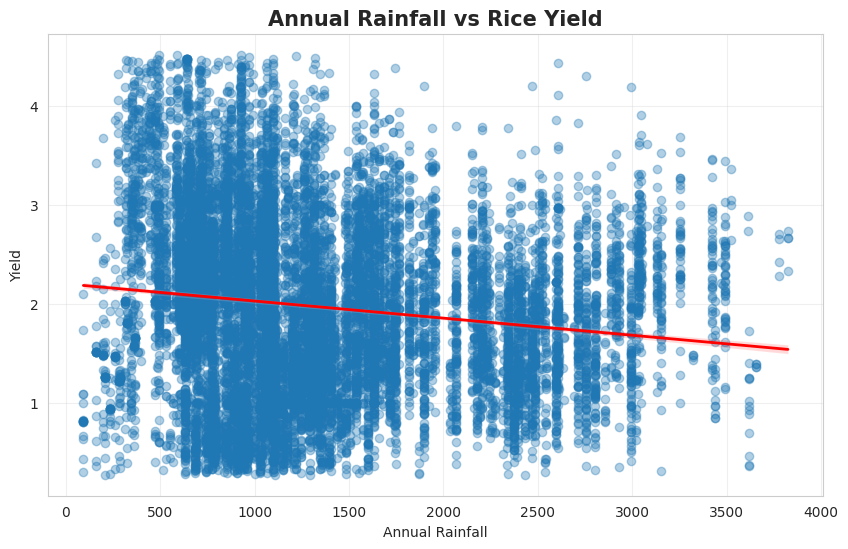

In [105]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=merged_df,
    x="ANNUAL",
    y="Yield",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Annual Rainfall vs Rice Yield", fontsize=15, weight="bold")
plt.xlabel("Annual Rainfall")
plt.ylabel("Yield")
plt.grid(alpha=0.3)
plt.show()

#Monsoon Rainfall vs Yield

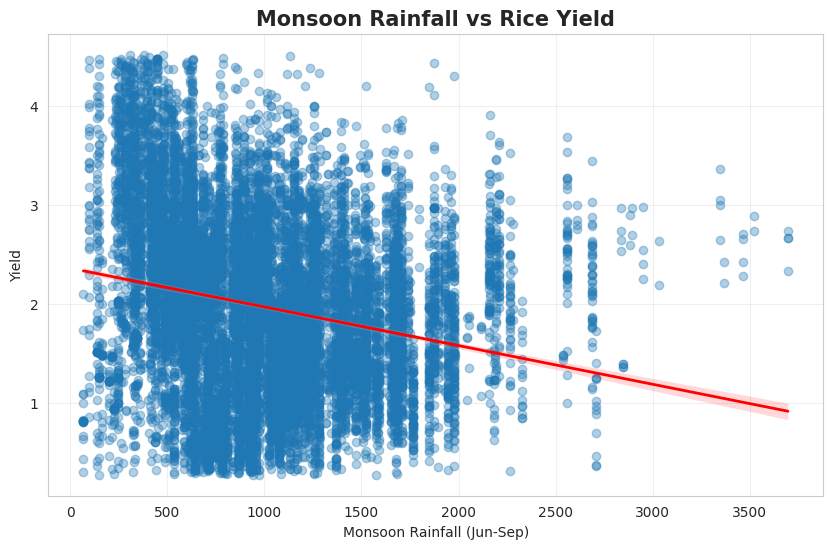

In [106]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=merged_df,
    x="Jun-Sep",
    y="Yield",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Monsoon Rainfall vs Rice Yield", fontsize=15, weight="bold")
plt.xlabel("Monsoon Rainfall (Jun-Sep)")
plt.ylabel("Yield")
plt.grid(alpha=0.3)
plt.show()

This is one of the most important plots because rice cultivation strongly depends on monsoon rainfall.

#Top 10 Rice Producing States

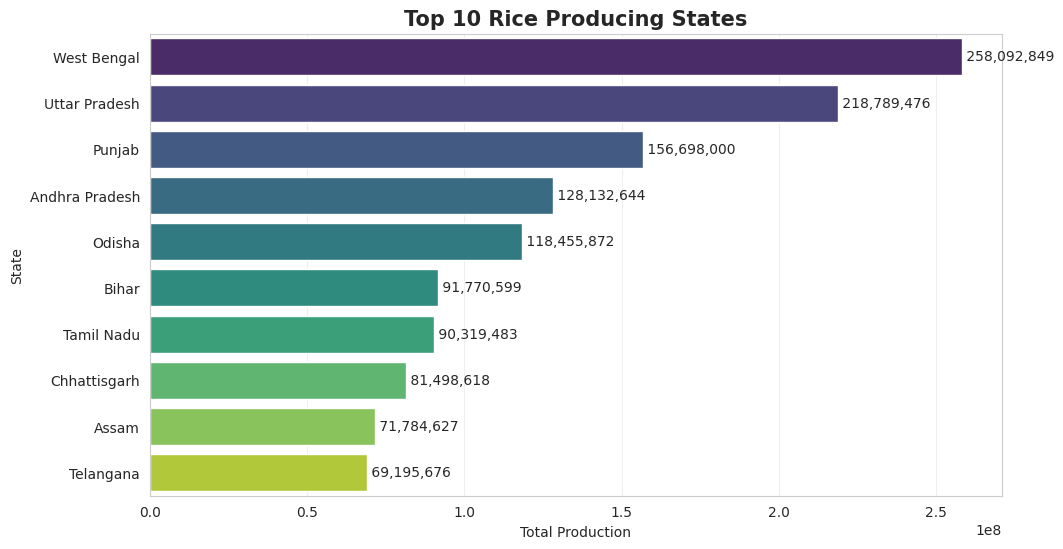

In [107]:
top_states = merged_df.groupby("State_Name")["Production"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=top_states.values, y=top_states.index, palette="viridis")

for i, value in enumerate(top_states.values):
    ax.text(value, i, f" {value:,.0f}", va="center", fontsize=10)

plt.title("Top 10 Rice Producing States", fontsize=15, weight="bold")
plt.xlabel("Total Production")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.3)
plt.show()

#Average Yield by Season

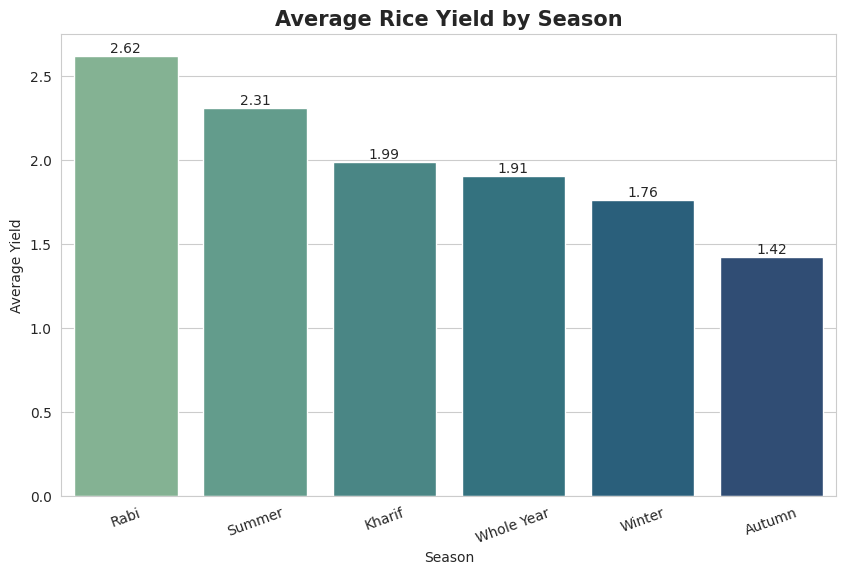

In [108]:
season_yield = merged_df.groupby("Season")["Yield"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=season_yield.index, y=season_yield.values, palette="crest")

for i, value in enumerate(season_yield.values):
    ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

plt.title("Average Rice Yield by Season", fontsize=15, weight="bold")
plt.xlabel("Season")
plt.ylabel("Average Yield")
plt.xticks(rotation=20)
plt.show()

#Correlation Heatmap

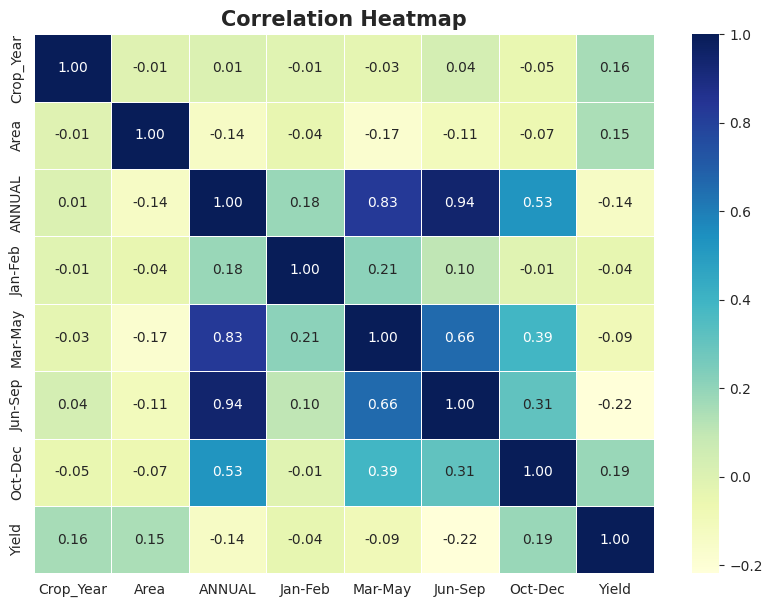

In [109]:
numeric_df = merged_df[
    ["Crop_Year", "Area", "ANNUAL", "Jan-Feb", "Mar-May", "Jun-Sep", "Oct-Dec", "Yield"]
]

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=15, weight="bold")
plt.show()

#Yield Trend Over Time

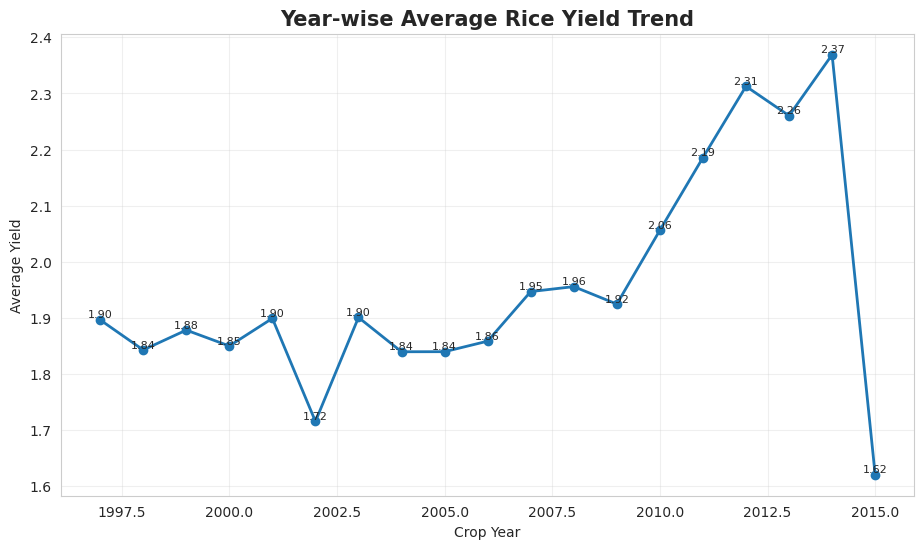

In [110]:
yearly_yield = merged_df.groupby("Crop_Year")["Yield"].mean().reset_index()

plt.figure(figsize=(11, 6))
plt.plot(yearly_yield["Crop_Year"], yearly_yield["Yield"], marker="o", linewidth=2)

for x, y in zip(yearly_yield["Crop_Year"], yearly_yield["Yield"]):
    plt.text(x, y, f"{y:.2f}", fontsize=8, ha="center", va="bottom")

plt.title("Year-wise Average Rice Yield Trend", fontsize=15, weight="bold")
plt.xlabel("Crop Year")
plt.ylabel("Average Yield")
plt.grid(alpha=0.3)
plt.show()

#Define Features and Target Variable
Explanation

Feature variables are the inputs used by the model.
Target variable is the value we want to predict.

In [111]:
X = merged_df[
    [
        "State_Name",
        "District_Name",
        "Season",
        "Crop_Year",
        "Area",
        "ANNUAL",
        "Jan-Feb",
        "Mar-May",
        "Jun-Sep",
        "Oct-Dec"
    ]
]

y = merged_df["Yield"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (14731, 10)
Target shape: (14731,)


In [112]:
categorical_features = ["State_Name", "District_Name", "Season"]
numeric_features = ["Crop_Year", "Area", "ANNUAL", "Jan-Feb", "Mar-May", "Jun-Sep", "Oct-Dec"]

##Build the Preprocessing Pipeline
Explanation

This pipeline:

fills missing values
scales numerical variables
converts text categories into machine-readable format

In [113]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

#Split Data into Training and Testing Sets
Explanation

We use 80% for training and 20% for testing.

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (11784, 10)
Testing data shape : (2947, 10)


#Define the Models
Explanation

We use three models:

Linear Regression
Random Forest
Gradient Boosting

In [115]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

#Train and Evaluate the Models
Explanation

We evaluate the models using:

MAE = Mean Absolute Error
RMSE = Root Mean Squared Error
R² Score = explained variance

In [116]:
results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print(results_df)

               Model       MAE      RMSE  R2 Score
1      Random Forest  0.338019  0.448775  0.742441
0  Linear Regression  0.340012  0.461225  0.727952
2  Gradient Boosting  0.410342  0.525629  0.646672


#Visual Comparison of Models

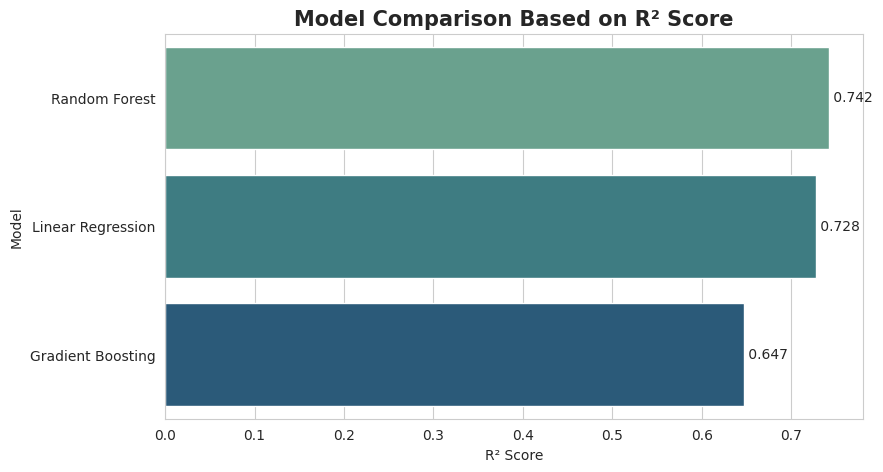

In [117]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_df, x="R2 Score", y="Model", palette="crest")

for i, value in enumerate(results_df["R2 Score"]):
    ax.text(value, i, f" {value:.3f}", va="center", fontsize=10)

plt.title("Model Comparison Based on R² Score", fontsize=15, weight="bold")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

#RMSE Comparison

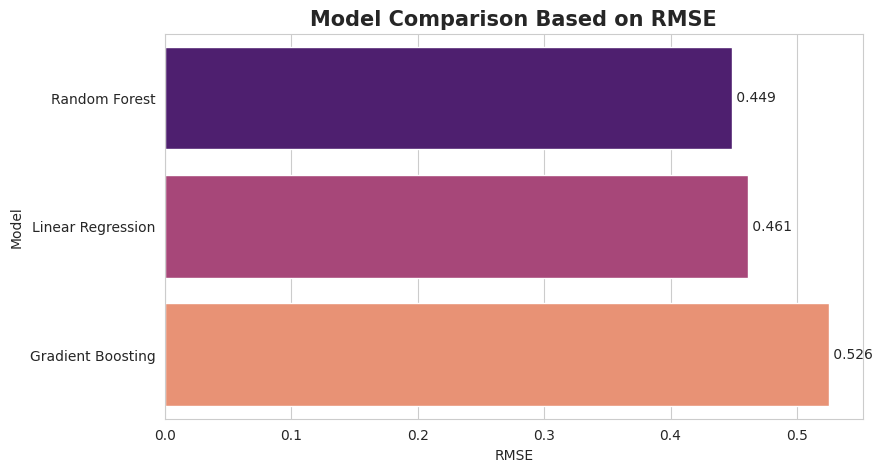

In [118]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_df, x="RMSE", y="Model", palette="magma")

for i, value in enumerate(results_df["RMSE"]):
    ax.text(value, i, f" {value:.3f}", va="center", fontsize=10)

plt.title("Model Comparison Based on RMSE", fontsize=15, weight="bold")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

#Train the Final Model
Explanation

Random Forest usually performs best for nonlinear agricultural data, so we choose it as the final model.

In [119]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

#Evaluate the Final Model

In [120]:
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

Final Model Performance
MAE : 0.338
RMSE: 0.4488
R2  : 0.7424


Random Forest performed best because it captured nonlinear agricultural patterns more effectively than other models. The final system can be further improved by adding soil, temperature, satellite, and forecasting data.

#Actual vs Predicted Plot

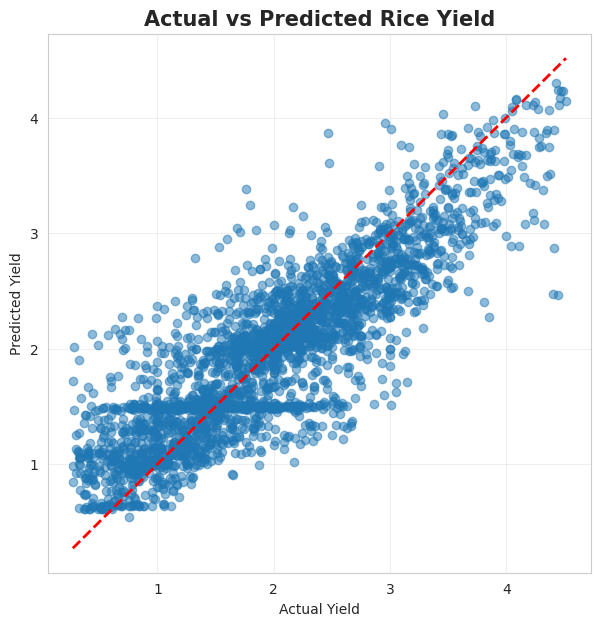

In [121]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Rice Yield", fontsize=15, weight="bold")

min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.grid(alpha=0.3)
plt.show()

#Residual Plot

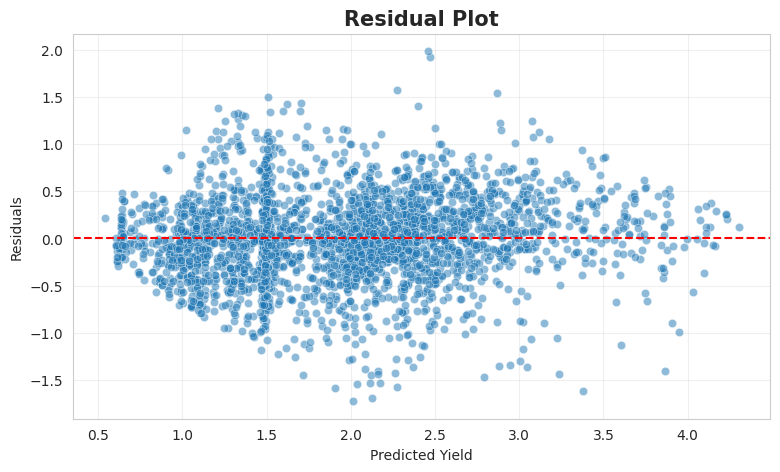

In [122]:
residuals = y_test - y_pred_final

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--", color="red")
plt.title("Residual Plot", fontsize=15, weight="bold")
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)
plt.show()

#Feature Importance Plot

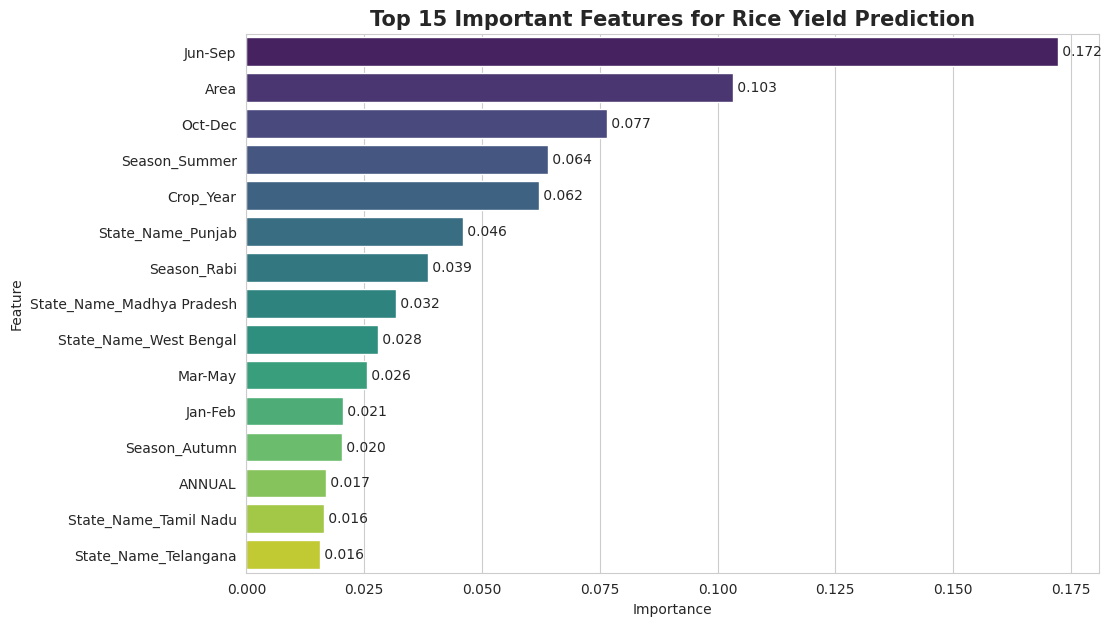

In [123]:
ohe = final_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)
importances = final_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(11, 7))
ax = sns.barplot(data=feature_importance_df, x="Importance", y="Feature", palette="viridis")

for i, value in enumerate(feature_importance_df["Importance"]):
    ax.text(value, i, f" {value:.3f}", va="center", fontsize=10)

plt.title("Top 15 Important Features for Rice Yield Prediction", fontsize=15, weight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [124]:
joblib.dump(final_model, "rice_yield_rainfall_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


#Predict Yield for a Future Input
Explanation

This code predicts rice yield for a new future input where the user gives expected conditions.

In [125]:
new_data = pd.DataFrame({
    "State_Name": ["Uttar Pradesh"],
    "District_Name": ["MAHARAJGANJ"],
    "Season": ["Kharif"],
    "Crop_Year": [2010],
    "Area": [1500],
    "ANNUAL": [1450],
    "Jan-Feb": [20],
    "Mar-May": [180],
    "Jun-Sep": [950],
    "Oct-Dec": [300]
})

predicted_yield = final_model.predict(new_data)[0]
estimated_production = predicted_yield * new_data["Area"].iloc[0]

print("Predicted Rice Yield:", round(predicted_yield, 3), "tons per hectare")
print("Estimated Total Production:", round(estimated_production, 3), "tons")

Predicted Rice Yield: 1.885 tons per hectare
Estimated Total Production: 2827.838 tons


#Future Prediction Validation

Historical vs Future Predicted Trend

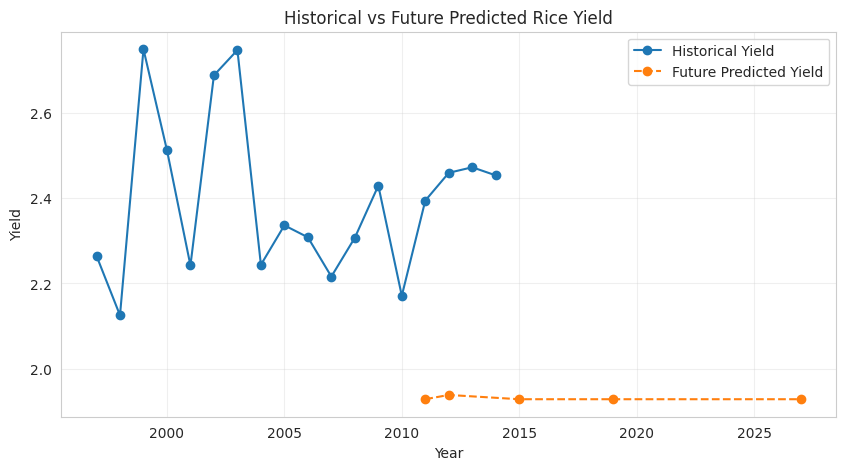

In [126]:
state_name = "Uttar Pradesh"
district_name = "MAHARAJGANJ"
season_name = "Kharif"
area_value = 1500

historical_data = merged_df[
    (merged_df["State_Name"] == state_name) &
    (merged_df["District_Name"] == district_name) &
    (merged_df["Season"] == season_name)
].copy()

historical_trend = historical_data.groupby("Crop_Year")["Yield"].mean().reset_index()

future_df = pd.DataFrame({
    "State_Name": [state_name] * 5,
    "District_Name": [district_name] * 5,
    "Season": [season_name] * 5,
    "Crop_Year": [2011,2012,2015,2019,2027],
    "Area": [area_value] * 5,
    "ANNUAL": [1450] * 5,
    "Jan-Feb": [20] * 5,
    "Mar-May": [180] * 5,
    "Jun-Sep": [950] * 5,
    "Oct-Dec": [300] * 5
})

future_df["Predicted_Yield"] = final_model.predict(future_df)

plt.figure(figsize=(10, 5))
plt.plot(historical_trend["Crop_Year"], historical_trend["Yield"], marker="o", label="Historical Yield")
plt.plot(future_df["Crop_Year"], future_df["Predicted_Yield"], marker="o", linestyle="--", label="Future Predicted Yield")

plt.title("Historical vs Future Predicted Rice Yield")
plt.xlabel("Year")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Time-Based Backtesting

In [127]:
features = [
    "State_Name",
    "District_Name",
    "Season",
    "Crop_Year",
    "Area",
    "ANNUAL",
    "Jan-Feb",
    "Mar-May",
    "Jun-Sep",
    "Oct-Dec"
]

train_df_time = merged_df[merged_df["Crop_Year"] <= 2010].copy()
test_df_time = merged_df[merged_df["Crop_Year"] > 2010].copy()

X_train_t = train_df_time[features]
y_train_t = train_df_time["Yield"]

X_test_t = test_df_time[features]
y_test_t = test_df_time["Yield"]

time_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

time_model.fit(X_train_t, y_train_t)
y_pred_t = time_model.predict(X_test_t)

mae_t = None
rmse_t = None
r2_t = None

try:
    mae_t = mean_absolute_error(y_test_t, y_pred_t)
    rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
    r2_t = r2_score(y_test_t, y_pred_t)
except Exception as e:
    print(f"Error calculating time-based metrics: {e}")

print("Time-Based Validation Results")
print("MAE :", round(mae_t, 4) if mae_t is not None else "N/A")
print("RMSE:", round(rmse_t, 4) if rmse_t is not None else "N/A")
print("R2  :", round(r2_t, 4) if r2_t is not None else "N/A")

Time-Based Validation Results
MAE : 0.5471
RMSE: 0.7139
R2  : 0.28


The R2 score of 0.28 indicates that the model explains about 28% of the variance in rice yield for the years after 2010. This is lower than the R2 score of 0.7424 obtained from the earlier random train-test split, suggesting that the model's performance may be less robust when predicting on future, unseen time periods compared to a random split of the same time period. This difference highlights the challenges of time-series prediction and potential changes in patterns over time.

### Predicted vs Actual Yield for Time-Based Backtesting

In [128]:
display(future_df)

,State_Name,District_Name,Season,Crop_Year,Area,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,Predicted_Yield
0,Uttar Pradesh,MAHARAJGANJ,Kharif,2011,1500,1450,20,180,950,300,1.928805
1,Uttar Pradesh,MAHARAJGANJ,Kharif,2012,1500,1450,20,180,950,300,1.938753
2,Uttar Pradesh,MAHARAJGANJ,Kharif,2015,1500,1450,20,180,950,300,1.928752
3,Uttar Pradesh,MAHARAJGANJ,Kharif,2019,1500,1450,20,180,950,300,1.928752
4,Uttar Pradesh,MAHARAJGANJ,Kharif,2027,1500,1450,20,180,950,300,1.928752


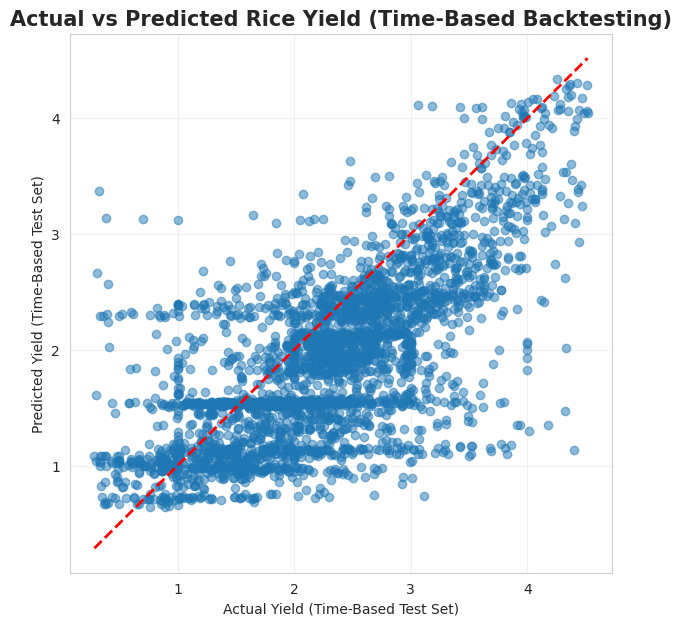

In [133]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_t, y_pred_t, alpha=0.5)
plt.xlabel("Actual Yield (Time-Based Test Set)")
plt.ylabel("Predicted Yield (Time-Based Test Set)")
plt.title("Actual vs Predicted Rice Yield (Time-Based Backtesting)", fontsize=15, weight="bold")

min_val_t = min(y_test_t.min(), y_pred_t.min())
max_val_t = max(y_test_t.max(), y_pred_t.max())
plt.plot([min_val_t, max_val_t], [min_val_t, max_val_t], "r--", linewidth=2)

plt.grid(alpha=0.3)
plt.show()

In [130]:
state_summary = merged_df.groupby("State_Name", as_index=False).agg({
    "Yield": "mean",
    "Production": "sum",
    "ANNUAL": "mean"
})

print(state_summary.head())

                    State_Name     Yield   Production       ANNUAL
0  Andaman and Nicobar Islands  2.725689     222994.0  2737.250000
1               Andhra Pradesh  2.849080  128132644.0  1051.122511
2            Arunachal Pradesh  1.185078    2708315.6  2482.595588
3                        Assam  1.593845   71784627.0  2369.559941
4                        Bihar  1.493345   91770599.0  1139.966306


In [131]:
total_states = state_summary["State_Name"].nunique()
avg_yield_india = state_summary["Yield"].mean()
top_state = state_summary.sort_values("Production", ascending=False).iloc[0]["State_Name"]

print("Total States Covered:", total_states)
print("Average Yield Across States:", round(avg_yield_india, 3))
print("Top Rice Producing State:", top_state)

Total States Covered: 33
Average Yield Across States: 2.075
Top Rice Producing State: West Bengal


In [132]:
import plotly.express as px

top_state_yield = state_summary.sort_values("Yield", ascending=False).head(15)

fig = px.bar(
    top_state_yield,
    x="Yield",
    y="State_Name",
    orientation="h",
    text="Yield",
    title="Top 15 States by Average Rice Yield"
)
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()